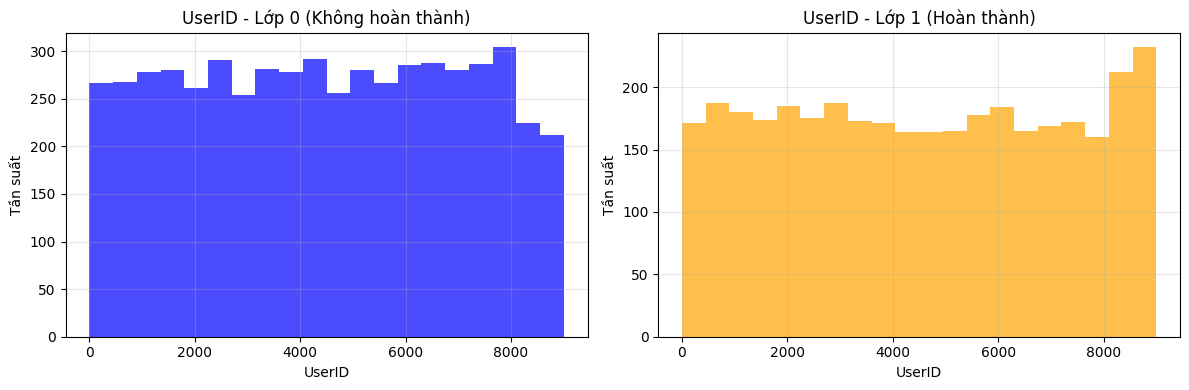

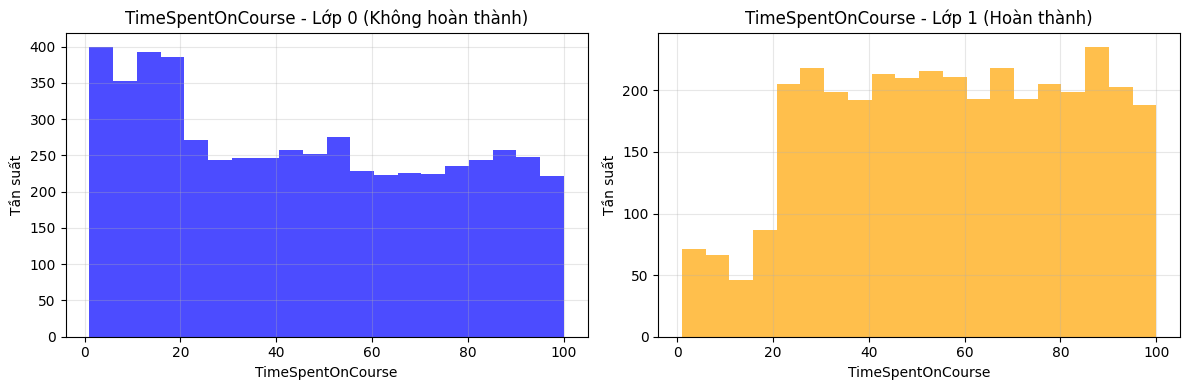

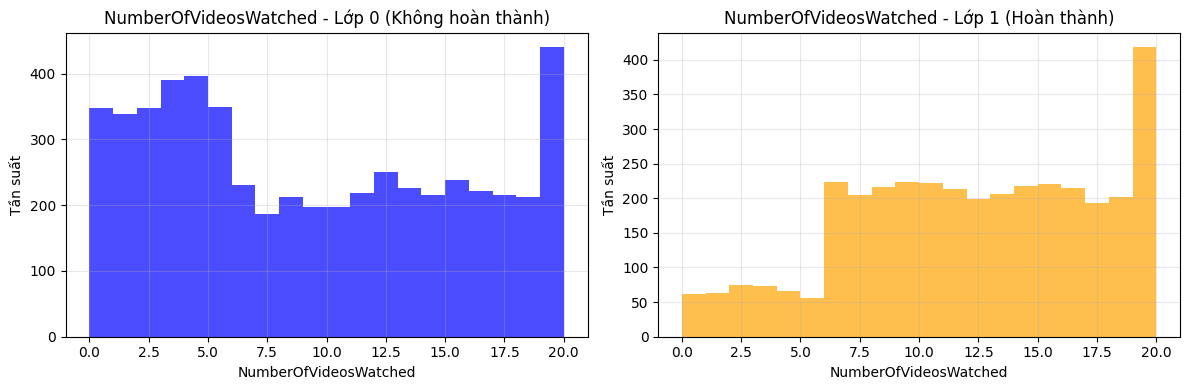

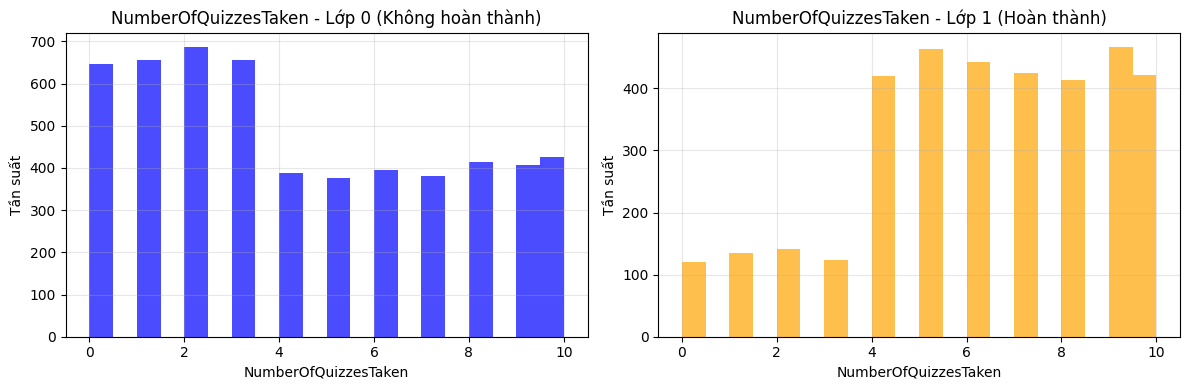

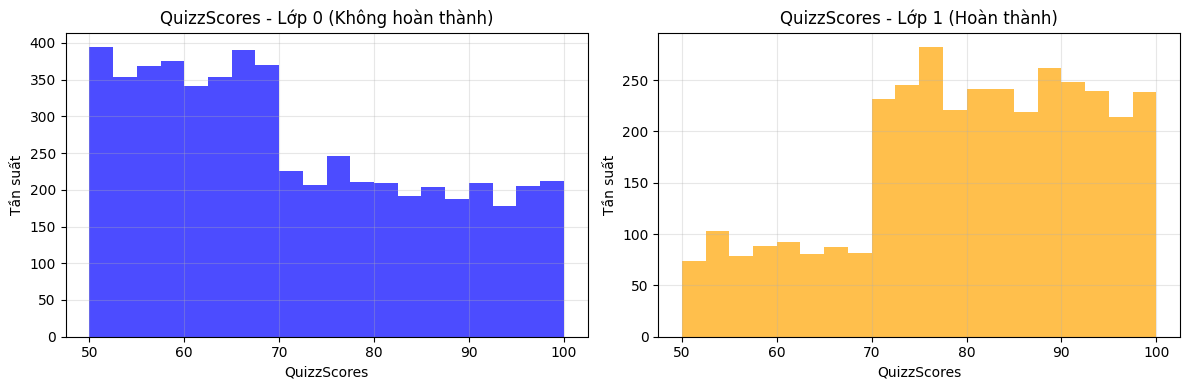

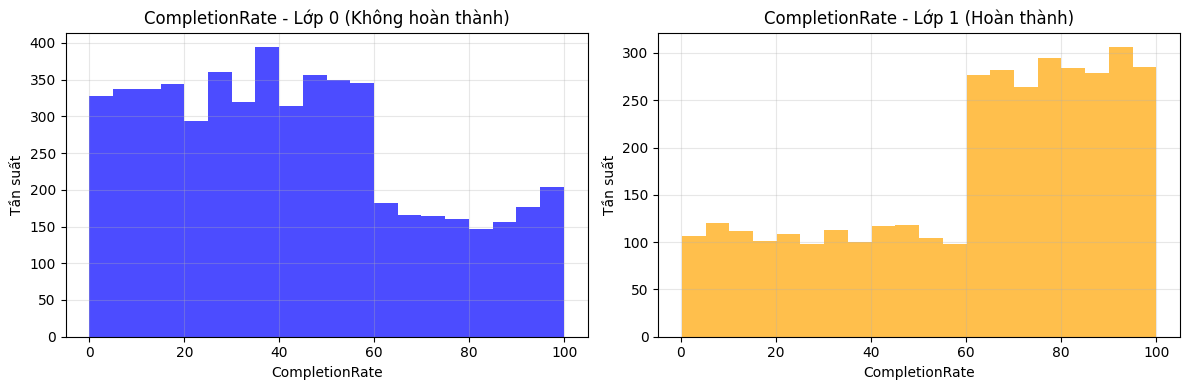

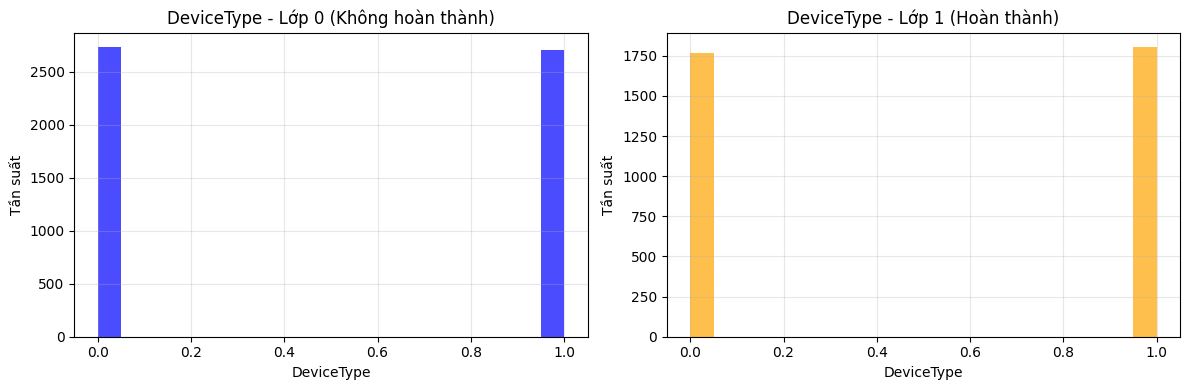

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("online_course_engagement_data.csv")

df_0 = df[df["CourseCompletion"] == 0]
df_1 = df[df["CourseCompletion"] == 1]

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove("CourseCompletion")

for col in num_cols:

    plt.figure(figsize=(12,4))

    # --- Subplot 1: Lớp 0 ---
    plt.subplot(1, 2, 1)
    plt.hist(df_0[col], bins=20, color="blue", alpha=0.7)
    plt.title(f"{col} - Lớp 0 (Không hoàn thành)")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.grid(alpha=0.3)

    # --- Subplot 2: Lớp 1 ---
    plt.subplot(1, 2, 2)
    plt.hist(df_1[col], bins=20, color="orange", alpha=0.7)
    plt.title(f"{col} - Lớp 1 (Hoàn thành)")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


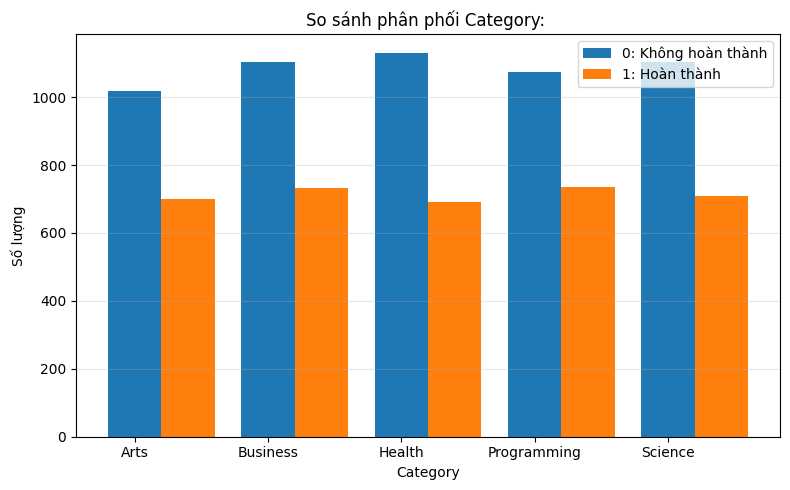

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("online_course_engagement_data.csv")

# Tách 2 nhóm completion
df_0 = df[df["CourseCompletion"] == 0]
df_1 = df[df["CourseCompletion"] == 1]

if "CourseCategory" in df.columns:

    # Đếm tần suất theo từng category cho 2 nhóm
    cat_0 = df_0["CourseCategory"].value_counts()
    cat_1 = df_1["CourseCategory"].value_counts()

    # Gộp chung tất cả category
    all_categories = sorted(df["CourseCategory"].unique())

    # Tạo list tần suất cho từng nhóm
    counts_0 = [cat_0.get(cat, 0) for cat in all_categories]
    counts_1 = [cat_1.get(cat, 0) for cat in all_categories]

    # Plot
    plt.figure(figsize=(8,5))
    x = range(len(all_categories))

    plt.bar(x, counts_0, width=0.4, label="0: Không hoàn thành")
    plt.bar([i+0.4 for i in x], counts_1, width=0.4, label="1: Hoàn thành")

    plt.xticks([i for i in x], all_categories)
    plt.xlabel("Category")
    plt.ylabel("Số lượng")
    plt.title("So sánh phân phối Category: ")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv("online_course_engagement_data.csv")

for name in ['userId', 'UserID', 'userid']:
    if name in df.columns:
        df = df.drop(columns=[name])

df = df.dropna()

df = pd.get_dummies(df, columns=["CourseCategory"], drop_first=False)

X = df.drop("CourseCompletion", axis=1)
print(X.head())
y = df["CourseCompletion"]
print(y.head())

   TimeSpentOnCourse  NumberOfVideosWatched  NumberOfQuizzesTaken  \
0               30.0                     17                     3   
1               27.8                      1                     5   
2               86.8                     14                     2   
3               35.0                     17                    10   
4               92.5                     16                     0   

   QuizzScores  CompletionRate  DeviceType  CourseCategory_Arts  \
0         50.4            20.9           1                False   
1         62.6            65.6           1                 True   
2         78.5            63.8           1                 True   
3         59.2            95.4           0                False   
4         98.4            18.1           0                False   

   CourseCategory_Business  CourseCategory_Health  CourseCategory_Programming  \
0                    False                   True                       False   
1                   

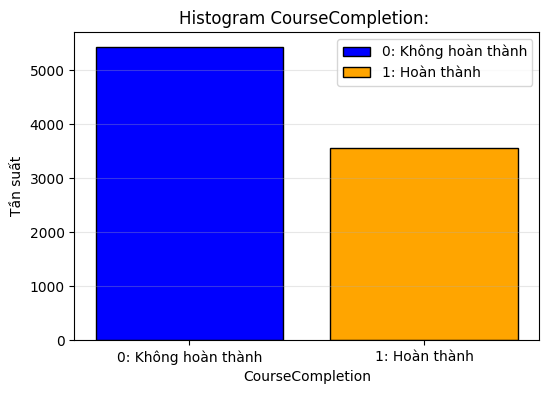

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("online_course_engagement_data.csv")

plt.figure(figsize=(6,4))

plt.hist(df[df["CourseCompletion"] == 0]["CourseCompletion"],
         bins=[-0.5, 0.5],
         color="blue", edgecolor="black", rwidth=0.8, label="0: Không hoàn thành")

plt.hist(df[df["CourseCompletion"] == 1]["CourseCompletion"],
         bins=[0.5, 1.5],
         color="orange", edgecolor="black", rwidth=0.8, label="1: Hoàn thành")

plt.xticks([0, 1], ["0: Không hoàn thành", "1: Hoàn thành"])
plt.xlabel("CourseCompletion")
plt.ylabel("Tần suất")
plt.title("Histogram CourseCompletion: ")
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()


In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Relative Importance')
plt.title('Feature Importances (Random Forest) - >= 1%')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

NameError: name 'importance_df' is not defined

<Figure size 800x600 with 0 Axes>

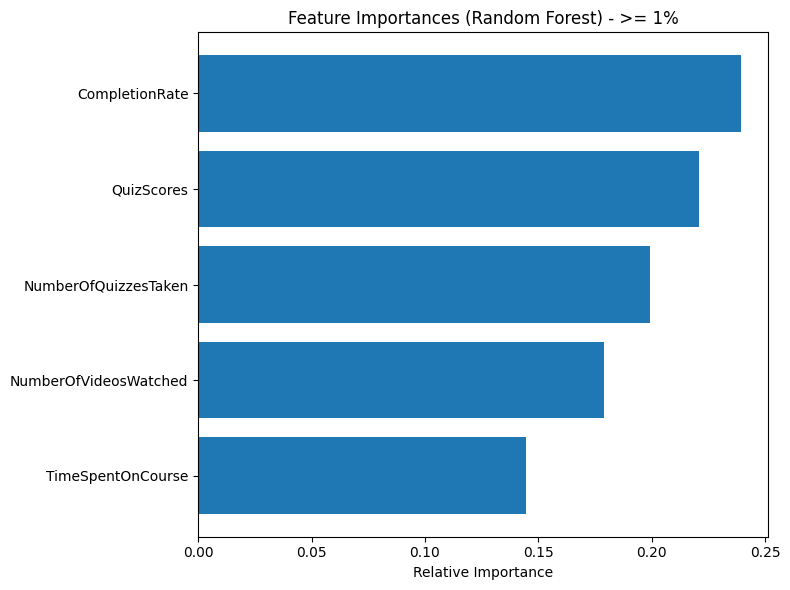

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(importance_new['feature'], importance_new['importance'])
plt.xlabel('Relative Importance')
plt.title('Feature Importances (Random Forest) - >= 1%')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

model = RandomForestClassifier(n_estimators=100, max_depth=10)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10)

In [ ]:
importance = model.feature_importances_
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(importance_df)

                       feature  importance
4               CompletionRate    0.247132
3                  QuizzScores    0.226857
2         NumberOfQuizzesTaken    0.195124
1        NumberOfVideosWatched    0.164015
0            TimeSpentOnCourse    0.149631
5                   DeviceType    0.004288
6          CourseCategory_Arts    0.002797
9   CourseCategory_Programming    0.002624
7      CourseCategory_Business    0.002579
10      CourseCategory_Science    0.002482
8        CourseCategory_Health    0.002471


In [ ]:
y_predict = model.predict(X_test)
print(importance_df[['feature', 'pct_importance']])

# Ma trận nhầm lẫn
TP = FP = TN = FN = 0
for yt, yp in zip(y_test, y_predict):
    if yt == 1 and yp == 1:
        TP += 1
    elif yt == 0 and yp == 0:
        TN += 1
    elif yt == 0 and yp == 1:
        FP += 1
    elif yt == 1 and yp == 0:
        FN += 1

cm_manual = [[TN, FP],
             [FN, TP]]

print("Ma trận nhầm lẫn: ")
print(cm_manual)

# tính độ chính xác dự đoán là 0
accuracy_0 = TN / (TN + FN)
print("Chính xác cho dự đoán là 0:", accuracy_0)

# tính độ recall là 0
recall_0 = TN/(TN + FP)
print("Recall cho dự đoán là 0:" , recall_0)

# tính độ chính xác dự đoán là 1
accuracy_1 = TP / (TP + FP)
print("Chính xác cho dự đoán là 1: ", accuracy_1)

# tính độ recall dự đoán là 1
recall_1 = TP / (TP + FN)
print("Recall cho dự đoán là 1: ", recall_1)

                       feature  importance
4               CompletionRate    0.247132
3                  QuizzScores    0.226857
2         NumberOfQuizzesTaken    0.195124
1        NumberOfVideosWatched    0.164015
0            TimeSpentOnCourse    0.149631
5                   DeviceType    0.004288
6          CourseCategory_Arts    0.002797
9   CourseCategory_Programming    0.002624
7      CourseCategory_Business    0.002579
10      CourseCategory_Science    0.002482
8        CourseCategory_Health    0.002471
Ma trận nhầm lẫn: 
[[1042, 36], [44, 678]]
Chính xác cho dự đoán là 0: 0.9594843462246777
Recall cho dự đoán là 0: 0.9666048237476809
Chính xác cho dự đoán là 1:  0.9495798319327731
Recall cho dự đoán là 1:  0.9390581717451524
